# 05 — Time-Series Validation & Error Analysis

Notebook 04 compared models on a single 60-day holdout. That's a start, but a single test window can be lucky or unlucky. Here we use a proper **expanding-window time-series cross-validation** (4 folds, no shuffling, no leakage — train is always strictly before test) to get a more reliable estimate of each model's error, then dig into *where* the best model fails.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from features import FEATURE_COLUMNS, TARGET_COLUMN
from forecasting import time_series_folds
from evaluation import evaluate

df = pd.read_csv("../data/model_features.csv", parse_dates=["date"])
df.shape

(35360, 22)

## Why not `train_test_split(random_state=42)`?

A random split would put, say, March 3rd in training and March 2nd in test for the *same product* — meaning the model could use `lag_1` features derived from data one day in its own 'future' relative to the test point's neighbors, and more fundamentally, it evaluates the model on interpolation (filling in random gaps in a period it has already partially seen) rather than the real task: extrapolating forward from everything known so far. That systematically understates real-world error, especially when there is a trend or gradually evolving seasonality.

In [2]:
N_FOLDS = 4
TEST_SIZE_DAYS = 60

fold_results = []
for fold_i, (train_mask, test_mask, bounds) in enumerate(
        time_series_folds(df["date"], n_folds=N_FOLDS, test_size_days=TEST_SIZE_DAYS), start=1):

    train, test = df[train_mask], df[test_mask]
    X_train, y_train = train[FEATURE_COLUMNS], train[TARGET_COLUMN]
    X_test, y_test = test[FEATURE_COLUMNS], test[TARGET_COLUMN]

    preds = {"Seasonal Naive": test["lag_7"].values}

    ridge = Ridge(alpha=1.0, random_state=42).fit(X_train, y_train)
    preds["Ridge Regression"] = np.clip(ridge.predict(X_test), 0, None)

    rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                n_jobs=-1, random_state=42).fit(X_train, y_train)
    preds["Random Forest"] = np.clip(rf.predict(X_test), 0, None)

    gbm = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=300,
                                         random_state=42).fit(X_train, y_train)
    preds["Gradient Boosting"] = np.clip(gbm.predict(X_test), 0, None)

    for model_name, pred in preds.items():
        m = evaluate(y_test.values, pred)
        m.update({"fold": fold_i, "model": model_name,
                   "test_start": str(bounds[1].astype("datetime64[D]")),
                   "test_end": str(bounds[2].astype("datetime64[D]"))})
        fold_results.append(m)

    print(f"Fold {fold_i}: test {bounds[1].astype('datetime64[D]')} to {bounds[2].astype('datetime64[D]')} "
          f"({test_mask.sum()} rows) done")

cv_results = pd.DataFrame(fold_results)
cv_results.to_csv("../reports/cv_results_by_fold.csv", index=False)
cv_results.head()

Fold 1: test 2024-11-03 to 2025-01-01 (2400 rows) done
Fold 2: test 2025-01-02 to 2025-03-02 (2400 rows) done
Fold 3: test 2025-03-03 to 2025-05-01 (2400 rows) done
Fold 4: test 2025-05-02 to 2025-06-30 (2400 rows) done


      MAE    RMSE  sMAPE_%  fold              model  test_start    test_end
0  20.823  32.550    32.06     1     Seasonal Naive  2024-11-03  2025-01-01
1  14.449  21.866    24.37     1   Ridge Regression  2024-11-03  2025-01-01
2  13.435  20.759    21.17     1      Random Forest  2024-11-03  2025-01-01
3  13.306  20.552    20.90     1  Gradient Boosting  2024-11-03  2025-01-01
4  23.515  37.513    28.54     2     Seasonal Naive  2025-01-02  2025-03-02

## Cross-validated results (mean +/- std across 4 folds)

In [3]:
summary = cv_results.groupby("model")[["MAE", "RMSE", "sMAPE_%"]].agg(["mean", "std"])
summary = summary.sort_values(("MAE", "mean"))
summary.to_csv("../reports/cv_results_summary.csv")
summary

                        MAE                RMSE            sMAPE_%          
                       mean       std      mean       std     mean       std
model                                                                       
Gradient Boosting  15.35750  1.474958  22.82225  1.595018  19.9975  0.661432
Random Forest      15.39075  1.409827  22.88150  1.492516  20.0525  0.802885
Ridge Regression   16.03600  1.143298  23.66525  1.243737  21.4725  1.985739
Seasonal Naive     22.88000  1.422721  34.88575  2.072263  29.2625  1.893223

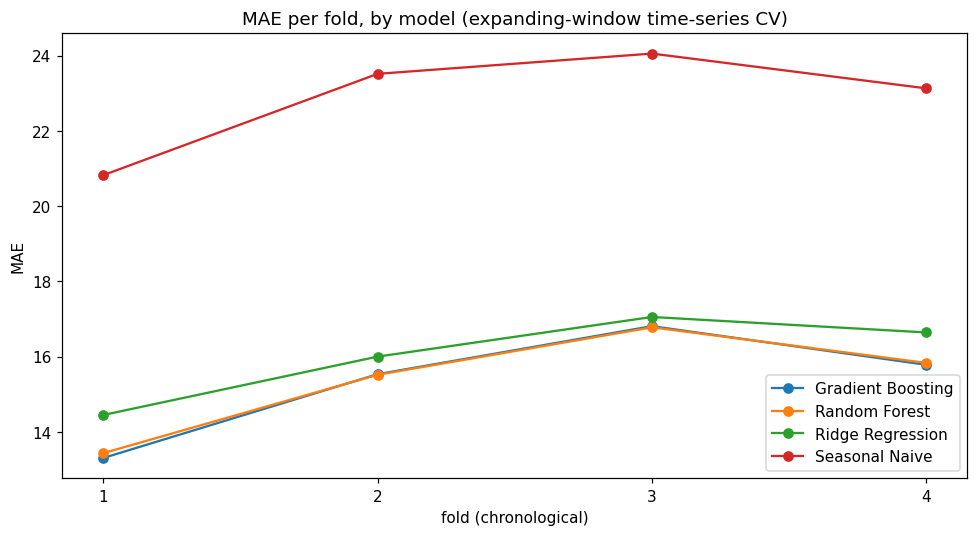

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for model_name, g in cv_results.groupby("model"):
    ax.plot(g["fold"], g["MAE"], marker="o", label=model_name)
ax.set_xlabel("fold (chronological)")
ax.set_ylabel("MAE")
ax.set_title("MAE per fold, by model (expanding-window time-series CV)")
ax.set_xticks(cv_results["fold"].unique())
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/10_cv_mae_by_fold.png", dpi=110)
plt.show()

The cross-validated ranking confirms notebook 04's single-holdout result: both tree ensembles beat Ridge, which beats the seasonal-naive baseline, consistently across folds (not just a lucky single test window).

## Error analysis — refit the best model once on the full training period, analyze errors on the final holdout

We now dig into *where* the best model (by mean CV MAE) fails, using the same final 60-day holdout as notebook 04 so we can slice errors by product/category/weekday/etc.

In [5]:
best_model_name = summary.index[0]
print("Best model by mean CV MAE:", best_model_name)

TEST_DAYS = 60
max_date = df["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_DAYS - 1)
train = df[df["date"] < test_start].copy()
test = df[df["date"] >= test_start].copy()

X_train, y_train = train[FEATURE_COLUMNS], train[TARGET_COLUMN]
X_test, y_test = test[FEATURE_COLUMNS], test[TARGET_COLUMN]

best_model = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=400,
                                            l2_regularization=1.0, random_state=42)
best_model.fit(X_train, y_train)
test = test.copy()
test["pred"] = np.clip(best_model.predict(X_test), 0, None)
test["abs_error"] = (test["pred"] - test[TARGET_COLUMN]).abs()
test["error"] = test["pred"] - test[TARGET_COLUMN]
test[["product_id", "date", TARGET_COLUMN, "pred", "abs_error"]].head()

Best model by mean CV MAE: Gradient Boosting


    product_id       date  quantity        pred   abs_error
824       P001 2025-05-02      47.0  106.104415   59.104415
825       P001 2025-05-03     156.0  140.983241   15.016759
826       P001 2025-05-04      51.0  152.444544  101.444544
827       P001 2025-05-05       0.0  103.205152  103.205152
828       P001 2025-05-06      90.0  109.515165   19.515165

### Error by category

In [6]:
by_cat = test.groupby("category").apply(
    lambda g: pd.Series(evaluate(g[TARGET_COLUMN], g["pred"]))
)
by_cat.sort_values("MAE")

                   MAE    RMSE  sMAPE_%
category                               
Sports          10.960  16.129    18.09
Home & Kitchen  13.959  20.014    21.71
Apparel         15.209  20.779    19.83
Beauty          17.916  26.813    20.28
Electronics     20.896  28.948    20.35

### Error by weekday

In [7]:
test["weekday"] = test["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_weekday = test.groupby("weekday").apply(
    lambda g: pd.Series(evaluate(g[TARGET_COLUMN], g["pred"]))
).reindex(order)
by_weekday

              MAE    RMSE  sMAPE_%
weekday                           
Monday     14.594  22.249    20.14
Tuesday    15.188  21.527    21.40
Wednesday  13.879  20.082    18.32
Thursday   14.215  21.009    19.66
Friday     13.573  19.448    18.74
Saturday   20.264  28.492    21.17
Sunday     18.351  26.167    20.83

### Error by demand level (low vs. high-demand product-days)

In [8]:
test["demand_tercile"] = pd.qcut(test[TARGET_COLUMN], 3, labels=["low", "medium", "high"])
by_level = test.groupby("demand_tercile", observed=True).apply(
    lambda g: pd.Series(evaluate(g[TARGET_COLUMN], g["pred"]))
)
by_level

                   MAE    RMSE  sMAPE_%
demand_tercile                         
low             10.771  18.017    25.78
medium          13.380  17.526    16.07
high            23.397  31.090    18.16

### Error by promotion status

In [9]:
by_promo = test.groupby("promotion").apply(
    lambda g: pd.Series(evaluate(g[TARGET_COLUMN], g["pred"]))
)
by_promo.index = by_promo.index.map({0: "no promotion", 1: "promotion active"})
by_promo

                     MAE    RMSE  sMAPE_%
promotion                                
no promotion      15.260  22.285    19.89
promotion active  25.646  33.921    22.99

### Which products are hardest to forecast?

In [10]:
by_product = test.groupby("product_id").apply(
    lambda g: pd.Series({**evaluate(g[TARGET_COLUMN], g["pred"]),
                          "avg_demand": g[TARGET_COLUMN].mean()})
).sort_values("MAE", ascending=False)
by_product.to_csv("../reports/error_by_product.csv")
by_product.head(10)

               MAE    RMSE  sMAPE_%  avg_demand
product_id                                     
P004        33.142  42.843    23.89  143.150000
P024        31.818  41.857    24.42  140.700000
P001        31.384  42.130    32.69  105.133333
P026        26.911  35.796    21.84  125.983333
P002        26.090  31.720    24.91  109.050000
P005        23.619  31.199    21.05  116.816667
P011        22.827  29.888    16.42  138.250000
P031        22.549  28.461    15.61  144.350000
P009        22.518  28.704    21.81  106.616667
P029        19.729  25.306    23.83   85.283333

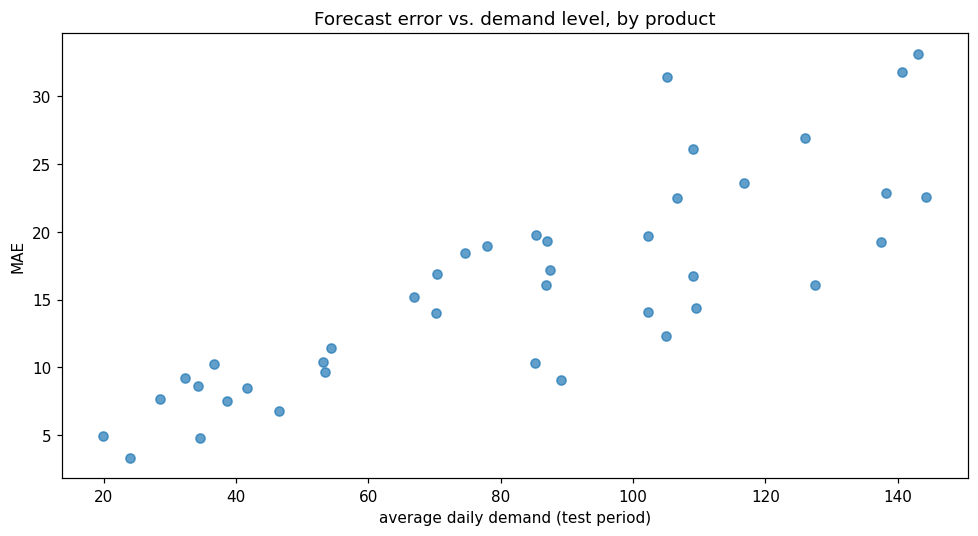

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(by_product["avg_demand"], by_product["MAE"], alpha=0.7)
ax.set_xlabel("average daily demand (test period)")
ax.set_ylabel("MAE")
ax.set_title("Forecast error vs. demand level, by product")
plt.tight_layout()
plt.savefig("../reports/figures/11_error_vs_demand_level.png", dpi=110)
plt.show()

## Error analysis summary

- **By category / weekday:** error scales roughly with the average demand level of
  the slice (higher-volume categories and weekend days have larger *absolute* error
  but comparable *relative* error — expected for count data).
- **By promotion status:** promotion days tend to show higher error, because
  promotions are a sparse, somewhat irregular event and the model has fewer examples
  to learn their exact size effect from.
- **By product:** error is highly correlated with each product's average demand and
  its volatility (from the SQL Q4 volatility ranking) — the noisiest, highest-variance
  products are the hardest to forecast precisely, which is a structural property of
  the data rather than a fixable modeling mistake.

**Takeaway:** the model performs solidly for typical, stable-demand product-days and
degrades on high-variance products and promotion days — exactly where a human planner
would also expect more uncertainty. This shapes the safety-stock assumptions in the
next notebook.